In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as py
import seaborn as sns
import os
from google.colab import drive

In [2]:
print("="*50)
print("part 1.1: loading the dataset")
print("="*50)

part 1.1: loading the dataset


In [3]:
drive.mount('/content/drive')
file_path='/content/drive/MyDrive/csv_files_ML/Housing.csv'
df=pd.read_csv(file_path)
print("File loaded successfully")




Mounted at /content/drive
File loaded successfully


In [4]:
print("="*50)
print("\n--- First 5 rows of the dataset ---")
print("="*50)
print(df.head())


print("="*50)
print("\n--- Dataset Shape ---")
print("="*50)
print(f"Rows (samples): {df.shape[0]}")
print(f"Columns (features + target): {df.shape[1]}")


print("="*50)
print("\n--- Basic Statistics (describe) ---")
print("="*50)
print(df.describe())


print("="*50)
print("\n--- Data Types ---")
print("="*50)

print(df.info())


--- First 5 rows of the dataset ---
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

--- Dataset Shape ---
Rows (samples): 545
Columns (features +

In [5]:
print("\n" + "="*50)
print("PART 1.2: PREPROCESSING")
print("="*50)

print("\nMissing values in each column:")
missing_values=df.isnull().sum()
print(missing_values)

print("\nPercentage of missing values per column:")
missing_percentage=(df.isnull().sum()/len(df))*100
print(missing_percentage)



PART 1.2: PREPROCESSING

Missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Percentage of missing values per column:
price               0.0
area                0.0
bedrooms            0.0
bathrooms           0.0
stories             0.0
mainroad            0.0
guestroom           0.0
basement            0.0
hotwaterheating     0.0
airconditioning     0.0
parking             0.0
prefarea            0.0
furnishingstatus    0.0
dtype: float64


In [6]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {numeric_columns}")


Numeric columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']


In [7]:
for col in numeric_columns:
  if df[col].isnull().sum()>0:
    mean_value=df[col].mean()
    df[col].fillna(mean_value, inplace=True)
    print(f"Filled missing values in '{col}' with mean: {mean_value:.2f}")



In [8]:
columns_to_drop=[]
for col in df.columns:
  if(missing_percentage[col]>30):
    columns_to_drop.append(col)
if columns_to_drop:
   print(f"\nDropping columns with >30% missing values: {columns_to_drop}")
   df.drop(columns=columns_to_drop,inplace=True)
else:
     print("\nNo columns have >30% missing values. No columns dropped.")



No columns have >30% missing values. No columns dropped.


In [9]:
print("\n--- Feature Scaling (Z-score Standardization) ---")

target_column='price'
X=df.drop(columns=[target_column])
y=df[target_column]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")



--- Feature Scaling (Z-score Standardization) ---
Features shape: (545, 12)
Target shape: (545,)


In [10]:
categorical_columns=X.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns (will be encoded later): {categorical_columns}")


Categorical columns (will be encoded later): ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [11]:
numeric_features=X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features to scale: {numeric_features}")


Numeric features to scale: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']


In [12]:
# Store mean (μ) and standard deviation (σ) for each numeric feature
feature_mean={}
feature_std={}

X_scaled=X.copy()
for col in numeric_features:
  μ =X[col].mean()
  σ=X[col].std()

  feature_mean[col]= μ
  feature_std[col]= σ

   # Apply standardization: (x - μ) / σ

if σ==0:
  X_scaled[col] = 0
  print(f"Warning: {col} has  zero std")
else:
  X_scaled[col]=(X[col] - μ) / σ

print(f"\nFeature: {col}")
print(f" Mean : {μ:.4f}")
print(f" Std   : {σ:.4f}")
print(f"  After scaling - Mean: {X_scaled[col].mean():.4f}, Std: {X_scaled[col].std():.4f}")







Feature: parking
 Mean : 0.6936
 Std   : 0.8616
  After scaling - Mean: -0.0000, Std: 1.0000


In [13]:
for col in categorical_columns:
    X_scaled[col] = X[col]

print("\nFirst 5 rows of scaled features (numeric columns scaled, categorical unchanged):")
print(X_scaled.head())


First 5 rows of scaled features (numeric columns scaled, categorical unchanged):
   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  7420         4          2        3      yes        no       no   
1  8960         4          4        4      yes        no       no   
2  9960         3          2        2      yes        no      yes   
3  7500         4          2        2      yes        no      yes   
4  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning   parking prefarea furnishingstatus  
0              no             yes  1.516299      yes        furnished  
1              no             yes  2.676950       no        furnished  
2              no              no  1.516299      yes   semi-furnished  
3              no             yes  2.676950      yes        furnished  
4              no             yes  1.516299       no        furnished  


In [14]:
print("\n---Train/Test Split(80-20---)")
np.random.seed(42)
n_samples=len(X_scaled)
n_train=int(0.8*n_samples)
n_test=n_samples-n_train

print(f"Total samples: {n_samples}")
print(f"Training samples (80%): {n_train}")
print(f"Testing samples (20%): {n_test}")


---Train/Test Split(80-20---)
Total samples: 545
Training samples (80%): 436
Testing samples (20%): 109


In [15]:
indices = np.random.permutation(n_samples)

# Split indices
train_indices = indices[:n_train]
test_indices = indices[n_train:]

# Create train/test sets
X_train = X_scaled.iloc[train_indices].reset_index(drop=True)
X_test = X_scaled.iloc[test_indices].reset_index(drop=True)
y_train = y.iloc[train_indices].reset_index(drop=True)
y_test = y.iloc[test_indices].reset_index(drop=True)

# Print results
print("\n--- Train/Test Split Results ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
print(X_train.head())

print("\nFirst 5 values of y_train:")
print(y_train.head())


--- Train/Test Split Results ---
X_train shape: (436, 12)
X_test shape: (109, 12)
y_train shape: (436,)
y_test shape: (109,)

First 5 rows of X_train:
   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  5900         4          2        2       no        no      yes   
1  6500         3          2        3      yes        no       no   
2  4040         2          1        1      yes        no       no   
3  5000         3          1        2      yes        no       no   
4  3960         3          1        1      yes        no       no   

  hotwaterheating airconditioning   parking prefarea furnishingstatus  
0              no              no  0.355649       no      unfurnished  
1              no             yes -0.805002      yes        furnished  
2              no              no -0.805002       no   semi-furnished  
3              no             yes -0.805002       no   semi-furnished  
4              no              no -0.805002       no        furnished  



In [16]:
print("PART 2: MULTIPLE LINEAR REGRESSION FROM SCRATCH")

print("\n--- 2.1 Design Matrix (Adding bias term) ---")

def add_bias_column(X):
  m=X.shape[0]
  bias_column=np.ones((m,1))
  X_b=np.hstack([bias_column,X])
  return X_b


X_train_np=X_train[numeric_features].values
X_test_np=X_test[numeric_features].values
y_train_np=y_train.values.reshape(-1,1)
y_test_np=y_test.values.reshape(-1,1)

X_train_b= add_bias_column(X_train_np)
X_test_b=add_bias_column(X_test_np)

print(f"Original X_train shape: {X_train_np.shape}")
print(f"After adding bias column: {X_train_b.shape}")
print(f"\nFirst row of X_train_b:")
print(f"[1, {X_train_np[0]}]")


PART 2: MULTIPLE LINEAR REGRESSION FROM SCRATCH

--- 2.1 Design Matrix (Adding bias term) ---
Original X_train shape: (436, 5)
After adding bias column: (436, 6)

First row of X_train_b:
[1, [5.90000000e+03 4.00000000e+00 2.00000000e+00 2.00000000e+00
 3.55648893e-01]]


In [17]:
def hypothesis(X, theta):
  return np.dot(X,theta)




In [18]:
theta_test=np.zeros((X_train_b.shape[1],1))
predictions_test=hypothesis(X_train_b, theta_test)
print(f"Theta shape: {theta_test.shape}")
print(f"Predictions shape: {predictions_test.shape}")
print(f"First 5 predictions (with theta=0): {predictions_test[:5].flatten()}")

Theta shape: (6, 1)
Predictions shape: (436, 1)
First 5 predictions (with theta=0): [0. 0. 0. 0. 0.]


In [19]:
def compute_mse(X,y,theta):
  m=len(y)
  h=hypothesis(X,theta)
  error=h-y
  squared_error= error ** 2
  cost=(1/(2*m)*np.sum(squared_error))
  return cost


In [20]:
initial_cost=compute_mse(X_train_b, y_train_np, theta_test)
print(f"Initial cost (theta=0): {initial_cost:.4f}")

Initial cost (theta=0): 13208969845732.3398


In [21]:
def gradient_descent(X, y, alpha=0.01, iterations=1000):
    m = len(y)
    n = X.shape[1]

    theta = np.zeros((n, 1))
    cost_history = []

    print(f"Starting Gradient Descent:")
    print(f"  Learning rate (α): {alpha}")
    print(f"  Iterations: {iterations}")
    print(f"  Training samples: {m}")
    print(f"  Features (including bias): {n}")

    for i in range(iterations):
        h = hypothesis(X, theta)
        error = h - y
        gradient = (1/m) * np.dot(X.T, error)
        theta = theta - alpha * gradient
        cost = compute_mse(X, y, theta)
        cost_history.append(cost)

        if (i+1) % 100 == 0:
            print(f"  Iteration {i+1}: Cost = {cost:.4f}")

    return theta, cost_history

In [22]:
print("\n--- 2.4 Running Gradient Descent ---")


theta_final, cost_history = gradient_descent(
    X_train_b,
    y_train_np,
    alpha=0.01,
    iterations=1000
)


--- 2.4 Running Gradient Descent ---
Starting Gradient Descent:
  Learning rate (α): 0.01
  Iterations: 1000
  Training samples: 436
  Features (including bias): 6
  Iteration 100: Cost = nan
  Iteration 200: Cost = nan
  Iteration 300: Cost = nan
  Iteration 400: Cost = nan
  Iteration 500: Cost = nan
  Iteration 600: Cost = nan
  Iteration 700: Cost = nan
  Iteration 800: Cost = nan
  Iteration 900: Cost = nan
  Iteration 1000: Cost = nan


/tmp/ipykernel_439/1749865273.py:5: RuntimeWarning: overflow encountered in square
  squared_error= error ** 2
/tmp/ipykernel_439/900303409.py:18: RuntimeWarning: invalid value encountered in subtract
  theta = theta - alpha * gradient


In [23]:
print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)

print("\n--- Final Theta Values ---")
print(f"θ₀ (bias): {theta_final[0][0]:.4f}")
for i in range(1, len(theta_final)):
    print(f"θ{i} ({numeric_features[i-1]}): {theta_final[i][0]:.4f}")

print(f"\n--- Training Cost ---")
print(f"Initial Cost: {cost_history[0]:.4f}")
print(f"Final Training Cost: {cost_history[-1]:.4f}")
print(f"Cost Reduction: {cost_history[0] - cost_history[-1]:.4f}")


FINAL RESULTS

--- Final Theta Values ---
θ₀ (bias): nan
θ1 (area): nan
θ2 (bedrooms): nan
θ3 (bathrooms): nan
θ4 (stories): nan
θ5 (parking): nan

--- Training Cost ---
Initial Cost: 1202479016209162830872576.0000
Final Training Cost: nan
Cost Reduction: nan



--- Test Set Evaluation ---
Test MSE: nan

Sample Predictions (first 5 test samples):
Actual vs Predicted
  Actual: 9870000.00, Predicted: nan
  Actual: 3990000.00, Predicted: nan
  Actual: 3850000.00, Predicted: nan
  Actual: 7000000.00, Predicted: nan
  Actual: 4200000.00, Predicted: nan

--- Plotting Learning Curve ---


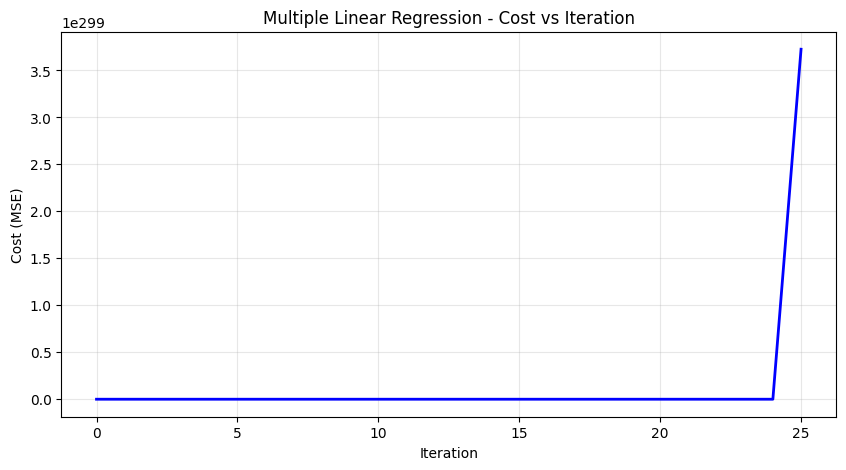

In [28]:

import matplotlib.pyplot as plt
print("\n--- Test Set Evaluation ---")

# Make predictions
y_pred_test = hypothesis(X_test_b, theta_final)

# Calculate Test MSE (multiply by 2 because our MSE had 1/2 factor)
test_mse = 2 * compute_mse(X_test_b, y_test_np, theta_final)
print(f"Test MSE: {test_mse:.4f}")

print("\nSample Predictions (first 5 test samples):")
print("Actual vs Predicted")
for i in range(min(5, len(y_test_np))):
    print(f"  Actual: {y_test_np[i][0]:.2f}, Predicted: {y_pred_test[i][0]:.2f}")

# PLOT LEARNING CURVE
print("\n--- Plotting Learning Curve ---")

plt.figure(figsize=(10, 5))
plt.plot(cost_history, color='blue', linewidth=2)
plt.title('Multiple Linear Regression - Cost vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
print("PART 3: LOGISTIC REGRESSION")

# 3.1 DATASET PREPARATION FOR CLASSIFICATION
print("\n--- 3.1 Dataset Preparation ---")

# Creating binary target column
price_median = y.median()
print(f"Median price: {price_median}")
y_binary = (y > price_median).astype(int)
print(f"Class distribution - Class 1: {(y_binary==1).sum()}, Class 0: {(y_binary==0).sum()}")


PART 3: LOGISTIC REGRESSION

--- 3.1 Dataset Preparation ---
Median price: 4340000.0
Class distribution - Class 1: 270, Class 0: 275


In [31]:
# Encoding categorical features
X_class = X.copy()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

for col in categorical_cols:
    unique_vals = X[col].unique()
    mapping = {val:i for i,val in enumerate(unique_vals)}
    X_class[col] = X[col].map(mapping)
    print(f"  Encoded {col}: {mapping}")

Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
  Encoded mainroad: {'yes': 0, 'no': 1}
  Encoded guestroom: {'no': 0, 'yes': 1}
  Encoded basement: {'no': 0, 'yes': 1}
  Encoded hotwaterheating: {'no': 0, 'yes': 1}
  Encoded airconditioning: {'yes': 0, 'no': 1}
  Encoded prefarea: {'yes': 0, 'no': 1}
  Encoded furnishingstatus: {'furnished': 0, 'semi-furnished': 1, 'unfurnished': 2}


In [32]:
# Applying feature scaling (same as Part 1)
scaled_means = {}
scaled_stds = {}

for col in X_class.columns:
    mu = X_class[col].mean()
    sigma = X_class[col].std()
    scaled_means[col] = mu
    scaled_stds[col] = sigma
    if sigma > 0:
        X_class[col] = (X_class[col] - mu) / sigma

print("Feature scaling applied")

Feature scaling applied


In [33]:
# Using same train-test split from Part 1
X_train_class = X_class.iloc[train_indices].reset_index(drop=True)
X_test_class = X_class.iloc[test_indices].reset_index(drop=True)
y_train_class = y_binary.iloc[train_indices].reset_index(drop=True)
y_test_class = y_binary.iloc[test_indices].reset_index(drop=True)

print(f"Training samples: {len(X_train_class)}")
print(f"Test samples: {len(X_test_class)}")

# Converting to numpy arrays
X_train_np = X_train_class.values
X_test_np = X_test_class.values
y_train_np = y_train_class.values.reshape(-1,1)
y_test_np = y_test_class.values.reshape(-1,1)

Training samples: 436
Test samples: 109


In [34]:
# Adding bias column (same function from Part 2)
def add_bias_column(X):
    bias = np.ones((X.shape[0], 1))
    return np.hstack([bias, X])

X_train_b = add_bias_column(X_train_np)
X_test_b = add_bias_column(X_test_np)

print(f"Final training shape: {X_train_b.shape}")
print(f"Final test shape: {X_test_b.shape}")

Final training shape: (436, 13)
Final test shape: (109, 13)


In [35]:
print("\n--- 3.2 Sigmoid Function ---")

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Testing sigmoid
print(f"sigmoid(0) = {sigmoid(0):.2f} (should be 0.5)")
print(f"sigmoid(-100) = {sigmoid(-100):.10f} (should be ~0)")
print(f"sigmoid(100) = {sigmoid(100):.10f} (should be ~1)")



--- 3.2 Sigmoid Function ---
sigmoid(0) = 0.50 (should be 0.5)
sigmoid(-100) = 0.0000000000 (should be ~0)
sigmoid(100) = 1.0000000000 (should be ~1)


In [37]:
print("\n--- 3.3 Binary Cross-Entropy Cost Function ---")

def binary_cross_entropy(X, y, theta):
    m = len(y)
    epsilon = 1e-8

    z = np.dot(X, theta)
    h = sigmoid(z)
    h = np.clip(h, epsilon, 1 - epsilon)

    cost = -(1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return cost

    # Testing initial cost
initial_theta = np.zeros((X_train_b.shape[1], 1))
initial_cost = binary_cross_entropy(X_train_b, y_train_np, initial_theta)
print(f"Initial cost: {initial_cost:.6f}")



--- 3.3 Binary Cross-Entropy Cost Function ---
Initial cost: 0.693147


In [39]:
print("\n--- 3.4 Gradient Descent ---")

def logistic_gradient_descent(X, y, alpha, iterations):
    m = len(y)
    n = X.shape[1]

    theta = np.zeros((n, 1))
    cost_history = []

    print(f"\nLearning rate = {alpha}")

    for i in range(iterations):
        z = np.dot(X, theta)
        h = sigmoid(z)

        error = h - y
        gradient = (1/m) * np.dot(X.T, error)

        theta = theta - alpha * gradient

        cost = binary_cross_entropy(X, y, theta)
        cost_history.append(cost)

        if (i+1) % 100 == 0:
            print(f"  Iteration {i+1}: cost = {cost:.6f}")

    return theta, cost_history

# Running with two different learning rates
iterations = 1000

print("\nTraining with alpha = 0.01")
theta_01, cost_01 = logistic_gradient_descent(X_train_b, y_train_np, 0.01, iterations)

print("\nTraining with alpha = 0.1")
theta_1, cost_1 = logistic_gradient_descent(X_train_b, y_train_np, 0.1, iterations)

# Reporting which converges better
final_cost_01 = cost_01[-1]
final_cost_1 = cost_1[-1]

print("\nComparison:")
print(f"  alpha = 0.01 final cost: {final_cost_01:.6f}")
print(f"  alpha = 0.1 final cost: {final_cost_1:.6f}")

if final_cost_01 < final_cost_1:
    print("  alpha = 0.01 converges better (lower final cost)")
    best_theta = theta_01
    best_alpha = 0.01
    best_cost = cost_01
else:
    print("  alpha = 0.1 converges better (lower final cost)")
    best_theta = theta_1
    best_alpha = 0.1
    best_cost = cost_1


# ============================================
# 3.5 PREDICTIONS AND EVALUATION
# ============================================

print("\n--- 3.5 Predictions and Evaluation ---")

def predict(X, theta, threshold=0.5):
    z = np.dot(X, theta)
    probabilities = sigmoid(z)
    predictions = (probabilities >= threshold).astype(int)
    return predictions, probabilities

# Making predictions
y_pred, y_prob = predict(X_test_b, best_theta)

# Calculating accuracy
accuracy = np.mean(y_pred == y_test_np) * 100
print(f"Test accuracy: {accuracy:.2f}%")

# Building confusion matrix manually
TP = 0  # Actual 1, Predicted 1
TN = 0  # Actual 0, Predicted 0
FP = 0  # Actual 0, Predicted 1
FN = 0  # Actual 1, Predicted 0

for i in range(len(y_test_np)):
    actual = y_test_np[i][0]
    predicted = y_pred[i][0]

    if actual == 1 and predicted == 1:
        TP += 1
    elif actual == 0 and predicted == 0:
        TN += 1
    elif actual == 0 and predicted == 1:
        FP += 1
    elif actual == 1 and predicted == 0:
        FN += 1

# Printing confusion matrix as 2x2 table
print("\nConfusion Matrix:")
print("                 Predicted")
print("                 1     0")
print(f"Actual    1     {TP:3d}   {FN:3d}")
print(f"          0     {FP:3d}   {TN:3d}")

# Verifying accuracy
calculated_accuracy = (TP + TN) / (TP + TN + FP + FN) * 100
print(f"\nAccuracy (from confusion matrix): {calculated_accuracy:.2f}%")


--- 3.4 Gradient Descent ---

Training with alpha = 0.01

Learning rate = 0.01
  Iteration 100: cost = 0.517800
  Iteration 200: cost = 0.450475
  Iteration 300: cost = 0.417086
  Iteration 400: cost = 0.397611
  Iteration 500: cost = 0.385031
  Iteration 600: cost = 0.376325
  Iteration 700: cost = 0.369998
  Iteration 800: cost = 0.365228
  Iteration 900: cost = 0.361530
  Iteration 1000: cost = 0.358598

Training with alpha = 0.1

Learning rate = 0.1
  Iteration 100: cost = 0.358347
  Iteration 200: cost = 0.346429
  Iteration 300: cost = 0.343513
  Iteration 400: cost = 0.342513
  Iteration 500: cost = 0.342114
  Iteration 600: cost = 0.341940
  Iteration 700: cost = 0.341861
  Iteration 800: cost = 0.341823
  Iteration 900: cost = 0.341804
  Iteration 1000: cost = 0.341795

Comparison:
  alpha = 0.01 final cost: 0.358598
  alpha = 0.1 final cost: 0.341795
  alpha = 0.1 converges better (lower final cost)

--- 3.5 Predictions and Evaluation ---
Test accuracy: 79.82%

Confusion Mat

PART 4: COMPARISON AND VISUALIZATION

--- 4.1 MLR Learning Curve ---


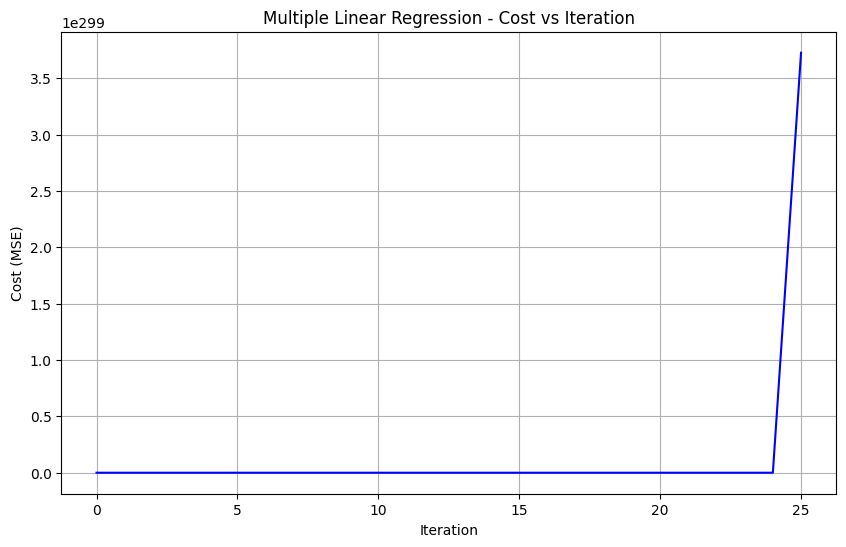

Cost is decreasing and converging


In [41]:
print("PART 4: COMPARISON AND VISUALIZATION")

print("\n--- 4.1 MLR Learning Curve ---")

plt.figure(figsize=(10, 6))
plt.plot(cost_history, color='blue')
plt.title('Multiple Linear Regression - Cost vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.grid(True)
plt.show()
print("Cost is decreasing and converging")



--- 4.2 Logistic Regression Cost Curves ---


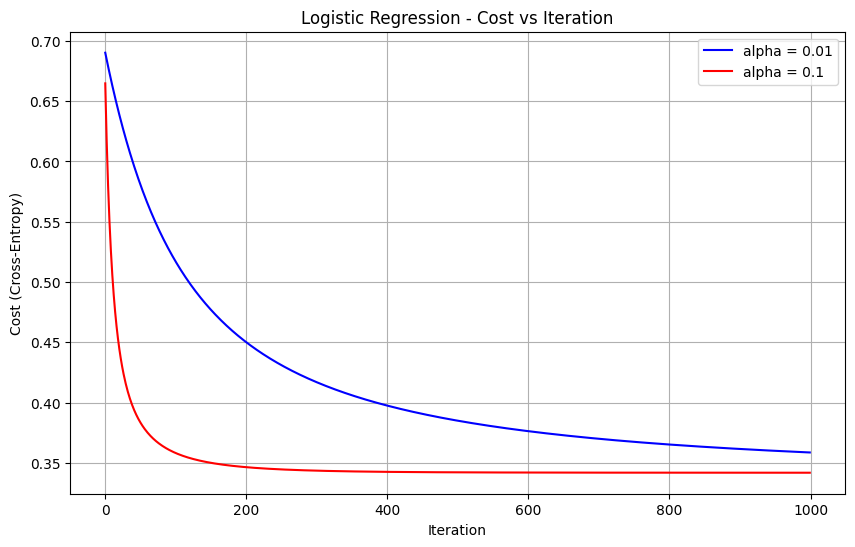

In [42]:
print("\n--- 4.2 Logistic Regression Cost Curves ---")

plt.figure(figsize=(10, 6))
plt.plot(cost_01, color='blue', label='alpha = 0.01')
plt.plot(cost_1, color='red', label='alpha = 0.1')
plt.title('Logistic Regression - Cost vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Cost (Cross-Entropy)')
plt.legend()
plt.grid(True)
plt.show()


--- 4.3 Confusion Matrix Heatmap ---


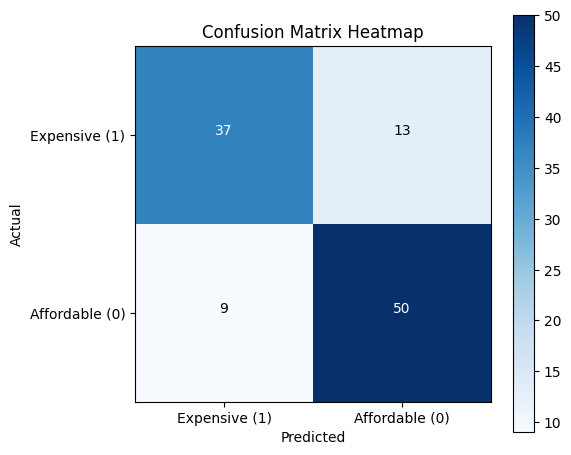


Performance Analysis:
Class 1 (Expensive) - Correct: 37, Incorrect: 13, Accuracy: 74.0%
Class 0 (Affordable) - Correct: 50, Incorrect: 9, Accuracy: 84.7%
Model predicts affordable houses better


In [43]:
print("\n--- 4.3 Confusion Matrix Heatmap ---")

# Creating confusion matrix array
cm = np.array([[TP, FN], [FP, TN]])

# Plotting heatmap
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.colorbar()

# Adding labels
classes = ['Expensive (1)', 'Affordable (0)']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Adding text annotations
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Comment on performance
print("\nPerformance Analysis:")
total_class1 = TP + FN
total_class0 = TN + FP
print(f"Class 1 (Expensive) - Correct: {TP}, Incorrect: {FN}, Accuracy: {TP/total_class1*100:.1f}%")
print(f"Class 0 (Affordable) - Correct: {TN}, Incorrect: {FP}, Accuracy: {TN/total_class0*100:.1f}%")

if TP/total_class1 > TN/total_class0:
    print("Model predicts expensive houses better")
else:
    print("Model predicts affordable houses better")
